In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import export_text
from sklearn.preprocessing import MinMaxScaler

In [57]:

def read_data(data_path):
    # Read the data
    raw_data = np.genfromtxt(data_path, delimiter=',')
    
    y = raw_data[:, 0]  # Signal
    x = raw_data[:, 1]  # Time

    scaler = MinMaxScaler()

    x = x*1e-6
    y = y.reshape(-1, 1)
    y = scaler.fit_transform(y).flatten()

    df = pd.DataFrame({"Time": x.flatten(), "Signal": y.flatten()})

    #Standardize time so the first point is at 0 seconds
    df["Time"] = df["Time"] - min(df["Time"])
    
    return df

def clean_data(df, interval_times, start_time):

    scaler = MinMaxScaler()
    print(df.tail(10))
    # Filter out data before the start time
    cleaned = df[df["Time"] >= start_time].copy()
    
    print(cleaned.head(10))

    # Label each point with a State based on the interval
    start_time_copy = start_time
    for i in range(len(interval_times)):
        end_time = start_time_copy + interval_times[i]
        cleaned.loc[cleaned["Time"].between(start_time_copy, end_time), "State"] = i%2  
        start_time_copy = end_time

    plt.plot(cleaned["Time"], cleaned["Signal"])
    plt.plot(cleaned["Time"], cleaned["State"])
    cleaned = cleaned[cleaned["State"].apply(lambda x: not (pd.isna(x) or x in [float('inf'), float('-inf')]))]
    plt.show()

    start_time_copy = start_time
    for i in range(len(interval_times)):
        end_time = start_time_copy + interval_times[i]
        if (i > 0):
            df_section = cleaned[cleaned['Time'].between(start_time_copy-4, end_time+4)].copy()
            plt.plot(df_section["Time"], df_section["Signal"])
            plt.plot(df_section["Time"], df_section["State"])
            plt.show()
        start_time_copy = end_time

    return cleaned



             Time  Signal
18657  198.867660  0.9989
18658  198.878372  0.9989
18659  198.889100  0.9989
18660  198.899812  0.9989
18661  198.910532  0.9989
18662  198.921260  0.9989
18663  198.931980  0.9989
18664  198.942708  0.9989
18665  198.953428  0.9989
18666  198.964156  0.9989
           Time    Signal
7069  75.300704  0.007701
7070  75.311328  0.007701
7071  75.321952  0.006601
7072  75.332576  0.006601
7073  75.343200  0.007701
7074  75.353832  0.006601
7075  75.364456  0.006601
7076  75.375080  0.007701
7077  75.385712  0.007701
7078  75.396336  0.008801


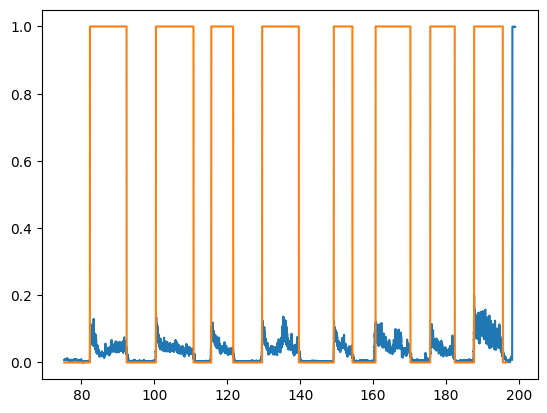

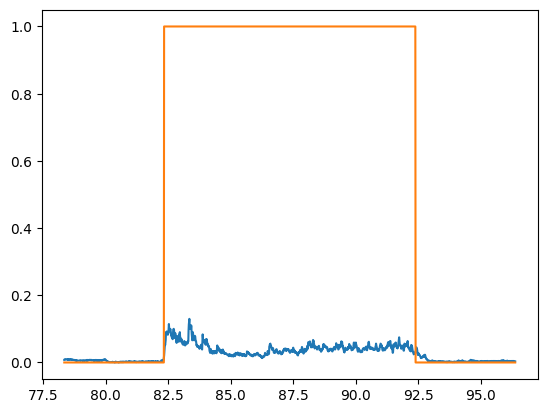

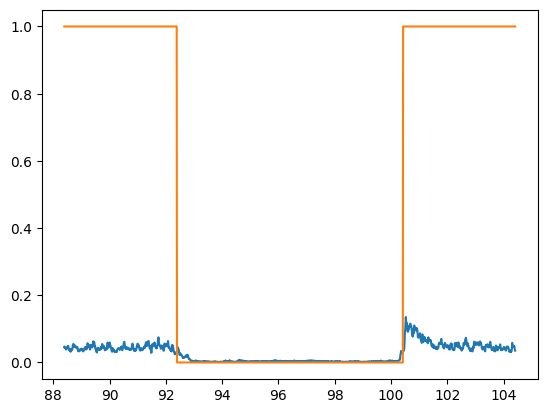

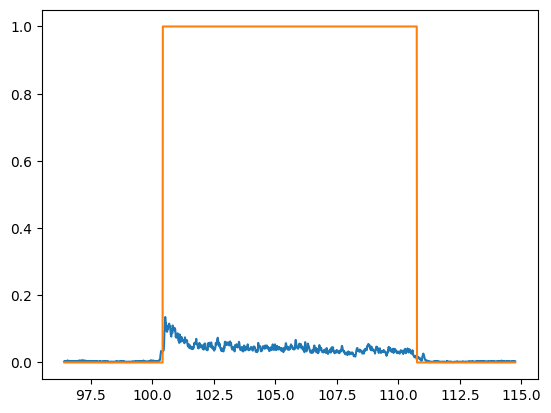

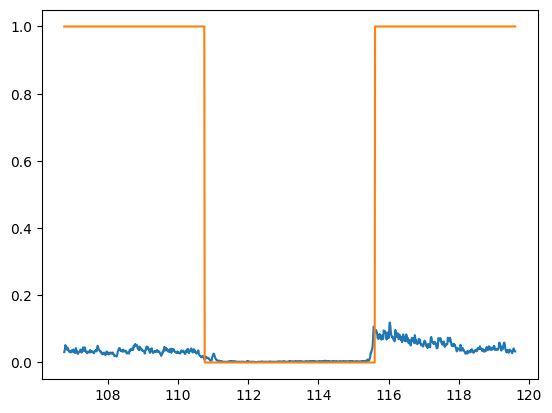

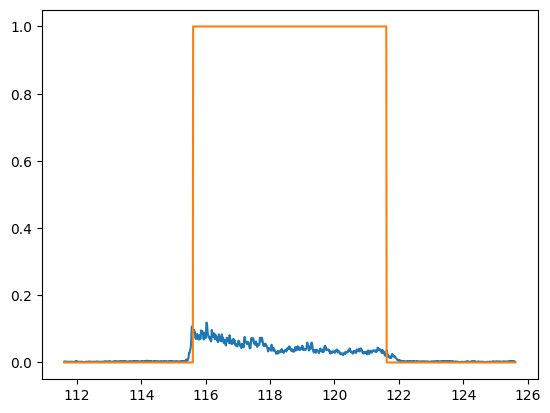

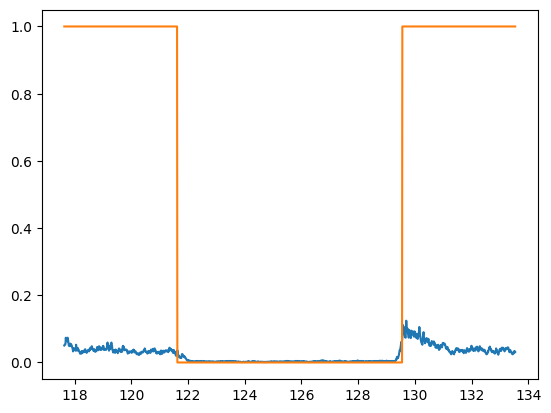

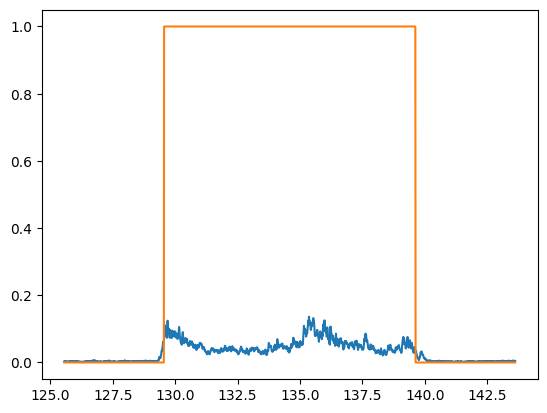

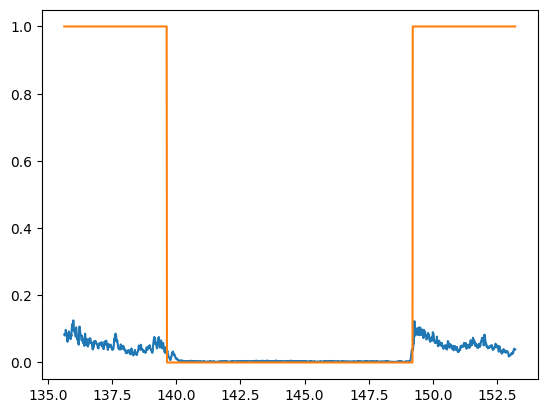

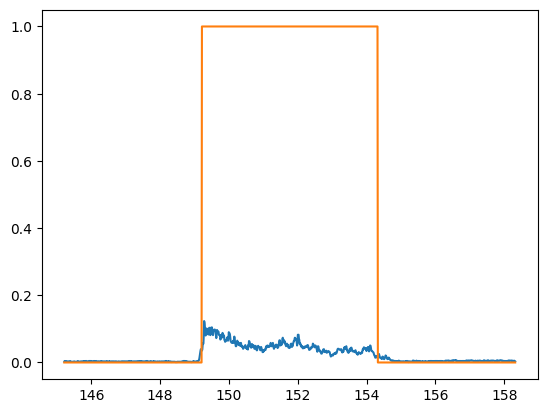

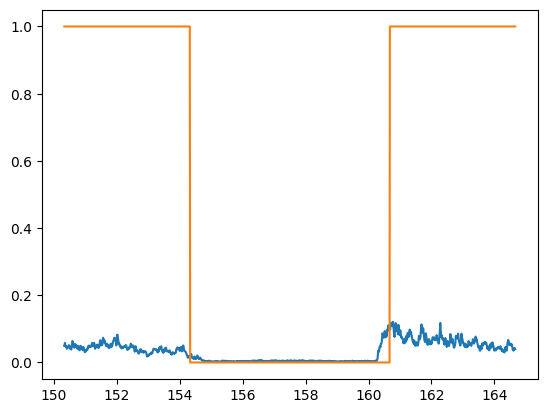

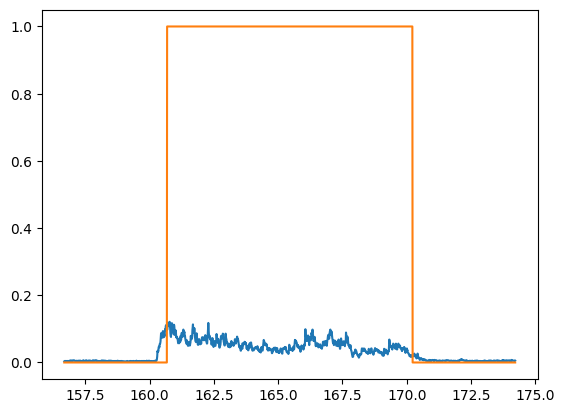

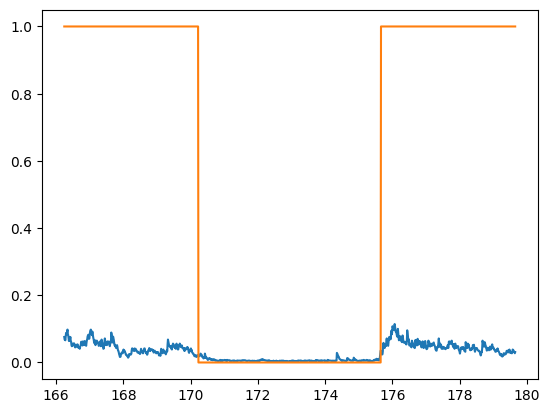

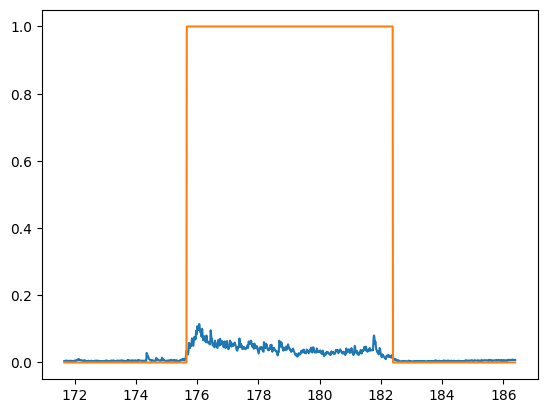

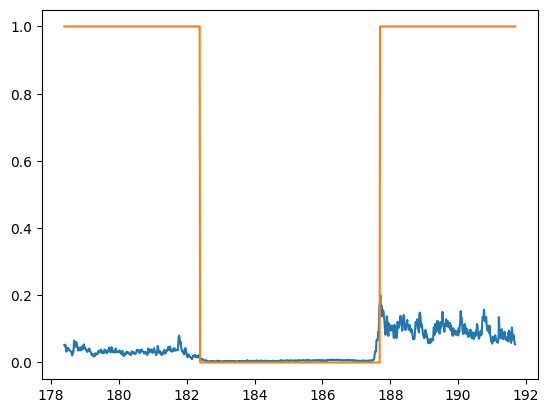

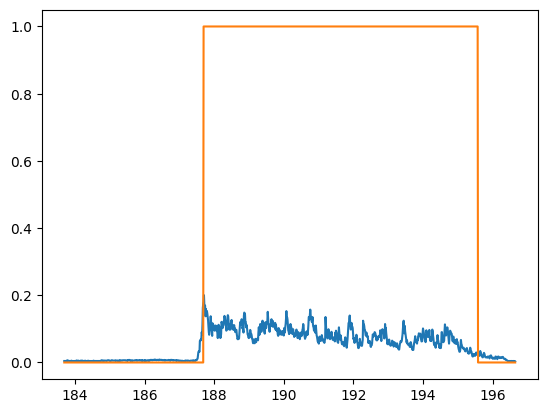

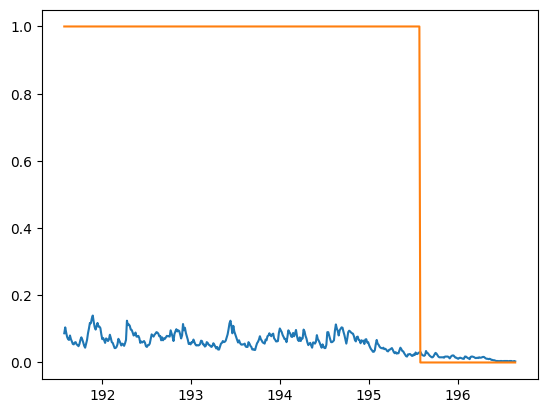

In [ ]:
data = read_data("/home/vivaan/Documents/Code/Projects/Bionic-Hand-Scripts/data/Spring 2026/lk_pressed_sidepos.csv")

interval_times_1 = [5.15, 4.53, 5.35, 5.25, 4.73, 5.03, 5.31, 4.38, 5.15, 5.31, 4.70, 4.75]
# 7.3

interval_times_2 = [10.08, 5.33, 5.20, 6.76, 6.91, 7.86, 7.63, 6.43, 7.26, 8.45, 10.00, 5.10, 7.33, 9.26, 5.73, 6.05, 5.46]
# 11.7

interval_times_3 = [7.03, 10.06, 8.03, 10.33, 4.86, 6.01, 7.93, 10.08, 9.58, 5.11, 6.35, 9.56, 5.43, 6.73, 5.30, 7.88, 1.08]
# 75.3

cleaned_data = clean_data(data, interval_times_3, 75.3)